In [1]:
import os
import xarray as xr
import sys
import itertools
from itertools import zip_longest
from lca_algebraic import initProject
import pandas as pd
import numpy as np
import xarray as xr
import pickle
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display
plt.rcParams['font.family'] = 'Times New Roman'
plt.style.use('tableau-colorblind10') #seaborn-v0_8-whitegrid

In [2]:
with open('output/BEV_comb_final_pGWP_df_list.pkl', 'rb') as f:
    bev = pickle.load(f)

## 1. enter use input for BEV bat_tech

In [3]:

# Define the first dropdown list
dropdown1 = widgets.Dropdown(
    options=['LFP', 'LSB', 'LTO', 'NCA', 'NMC622'],
    value='NMC622',
    description='Select initial bat tech:',
)

# Define the second dropdown list
dropdown2 = widgets.Dropdown(
    options=['LFP', 'LSB', 'LTO', 'NCA', 'NMC622'],
    value='LFP',
    description='Select bat replacement tech:',
)

# Variables to store the selected values, to be used as variable name 
bat1 = None
bat2 = None

# Function to handle the selection for the first dropdown
def on_change1(change):
    global bat1
    bat1 = change['new']
    print(f'Initial battery tech selected: {bat1}')

# Function to handle the selection for the second dropdown
def on_change2(change):
    global bat2
    bat2 = change['new']
    print(f'Battery replacement tech selected: {bat2}')

# Attach the functions to the dropdowns
dropdown1.observe(on_change1, names='value')
dropdown2.observe(on_change2, names='value')

# Display the dropdowns
display(dropdown1)
display(dropdown2)



Dropdown(description='Select initial bat tech:', index=4, options=('LFP', 'LSB', 'LTO', 'NCA', 'NMC622'), valu…

Dropdown(description='Select bat replacement tech:', options=('LFP', 'LSB', 'LTO', 'NCA', 'NMC622'), value='LF…

In [6]:
print(bat1, bat2)

NCA LSB


### choose the DF according to the user input tech:

In [7]:
for i in range(len(bev)):  
    if (bev[i][0].get('V1AB_init')) ==  bat1 and (bev[i][0].get('V1B')) ==  bat2:
        print(f'get index_number {i} from BEV dict for selected bat_tech') 
        bev_ind = i

get index_number 16 from BEV dict for selected bat_tech


In [8]:
#list[index][0] is the bat name, [1] is the dataframe stored 
mybevds = bev[bev_ind][1]
#mybevds
#assert not mybevds.isna().any().any(), "Selected tech is not available. Please re-enter battery technology"

## 1. get LCA DF prepared for ICEV and BEV (default 2 NMC)

In [9]:
mybevds2 = mybevds.dropna()
#mybevds2

In [10]:
mybevds2 = mybevds.dropna()

icev = pd.read_excel('ICEV_vlifecycle_finalLCA.xlsx') 
icev2 = icev[ (icev['SSP'].isin(list(np.unique(mybevds2["SSP"])))) &  (icev['v_year'].isin(list(np.unique(mybevds2["v_year"])))) ] 
#icev2
bev2 = mybevds2 #pd.read_excel('BEV_vlifecycle_2NMC_finalLCA.xlsx')
print(len(icev2), len(icev2))

18 18


In [11]:
bev2['Powertrain'] = 'BEV'
icev2['Powertrain'] = 'ICEV'

/var/folders/9p/gvkl7h6551515cs56m93ldgr0000gn/T/ipykernel_82926/1201547147.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bev2['Powertrain'] = 'BEV'
/var/folders/9p/gvkl7h6551515cs56m93ldgr0000gn/T/ipykernel_82926/1201547147.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  icev2['Powertrain'] = 'ICEV'


In [12]:
icev2 = icev2.rename(columns={'V1A': 'V1AB' }) 
#icev

## plot pGWP100 for both ICEV and BEV

In [13]:
df = pd.concat([bev2, icev2], ignore_index=True)
df = df[df['IC'] == 'pGWP100']
len(df)
#df.set_index( ['SSP', 'v_year', 'Powertrain' , 'IC' ])
#print(concatenated_df)

12

In [14]:
df[ (df['SSP'] =='ssp119') & (df['v_year'] ==2050 )] 

,SSP,v_year,IC,V1AB,F2,V1B,Powertrain,V2
7,ssp119,2050,pGWP100,125957.563620,9669.330577,31674.283834,BEV,NaN
25,ssp119,2050,pGWP100,82663.226564,-858523.524094,NaN,ICEV,832677.228951


### prepare df_list for ploting

In [15]:
df_list = []
for sp in ["ssp119","ssp245","ssp585"]: 
    for vy in [2030,2040,2050]: 
        dd = df [ (df['SSP'] == sp)  & (df['v_year'] == vy)   ]
        df_list.append(dd)

print(len(df_list))
df_list[8]

9


,SSP,v_year,IC,V1AB,F2,V1B,Powertrain,V2


## plot 

#### DO NOT plot BEV with unavailable bat

/var/folders/9p/gvkl7h6551515cs56m93ldgr0000gn/T/ipykernel_82926/3311372620.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha='right')
/var/folders/9p/gvkl7h6551515cs56m93ldgr0000gn/T/ipykernel_82926/3311372620.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha='right')
/var/folders/9p/gvkl7h6551515cs56m93ldgr0000gn/T/ipykernel_82926/3311372620.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha='right')


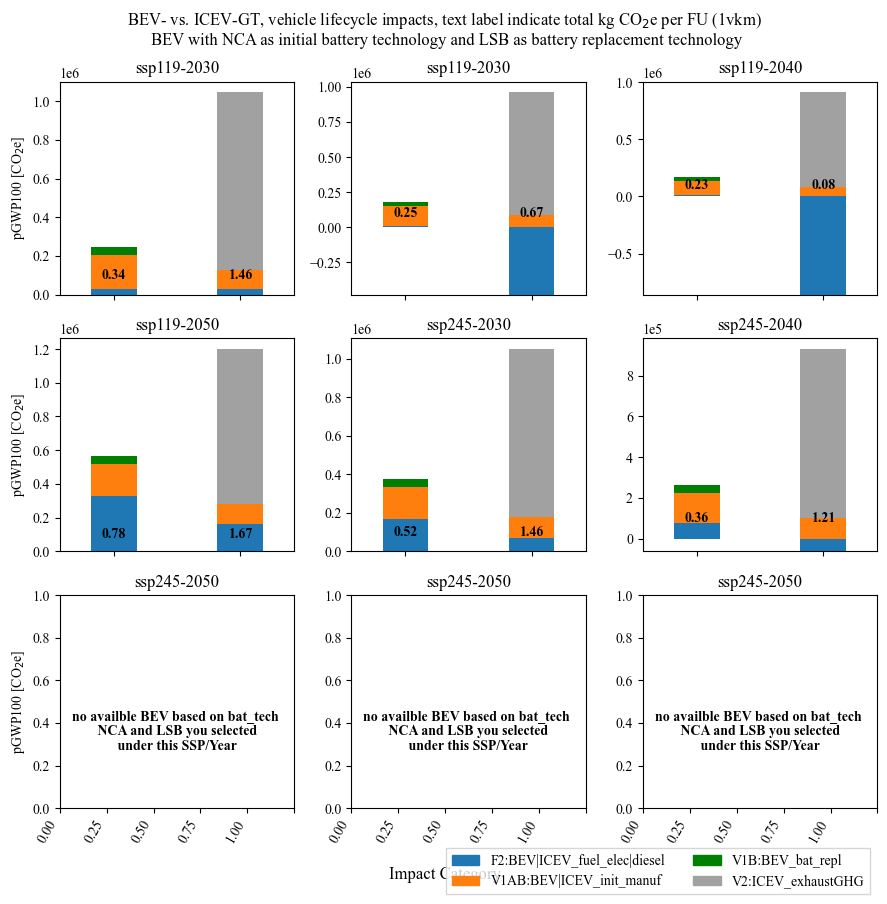

In [16]:
color_dict = {
    'F2':  '#1f77b4',   # blue
    'V1AB': '#ff7f0e',  # Orange
    'V1B': 'green',   #green
    'V2': '0.63',   # Medium gray
}
FU = 20*36000

fig, axs = plt.subplots(3, 3, figsize=(9, 9))
axs = axs.flatten()

for i in range(len(df_list)) :
    ax = axs[i]
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    #axs[i].grid(True, linestyle='--', linewidth=0.5, color='gray')
    subtitle =  str(df["SSP"].values[0]) + "-" + str(df["v_year"].values[0] )
    axs[i].set_title(subtitle)
    
    if len (df_list[i]) >1:  # only plot BEV with avilable tech
        df = df_list[i]
        ddf = df[[ 'Powertrain', 'IC', 'V1AB', 'F2', 'V1B', 'V2']]  
        pivot_df = ddf.pivot_table(index='Powertrain', columns='IC', values= [ 'V1AB', 'F2', 'V1B', 'V2'  ] ) 
        colors = [color_dict[col[0]] for col in pivot_df.columns]
        pivot_df.plot(kind='bar', ax=ax, stacked=True, legend=False, color=colors, title =subtitle, width=0.36, xlabel='' )
        
        # show text lable for lifecycle LCA score 
        columns_to_sum = ['V1AB', 'F2', 'V1B', 'V2']  
        bev_final_lca =  ddf[columns_to_sum].sum(axis=1).values[0] 
        icev_final_lca = ddf[columns_to_sum].sum(axis=1).values[1] 
        bev_lca_perfu = bev_final_lca / FU 
        icev_final_perfu = icev_final_lca / FU
        axs[i].text(0, 1e5, f'{bev_lca_perfu:.2f}', 
                    ha='center', va='center', fontsize=10, fontweight='bold', color='black')
        axs[i].text(1, 1e5, f'{icev_final_perfu:.2f}', 
                    ha='center', va='center', fontsize=10, fontweight='bold', color='black')
        
    else: 
        axs[i].text(0.5, 0.36, f'no availble BEV based on bat_tech \n {bat1} and {bat2} you selected \n under this SSP/Year ', 
                    ha='center', va='center', fontsize=10, fontweight='bold', color='black')
        
    # for ylables
    if i % 3 != 0:
        axs[i].set_ylabel('') 
    else: 
        axs[i].set_ylabel(r'pGWP100 [CO$_2$e]')
    
    # for xlables    
    if i<6:
        axs[i].set_xticklabels([])  
        axs[i].set_xlabel('') 
    else:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha='right')


# Add labels and title
tt =  f'BEV- vs. ICEV-GT, vehicle lifecycle impacts, text label indicate total kg CO$_2$e per FU (1vkm) \n BEV with {bat1} as initial battery technology and {bat2} as battery replacement technology'
fig.suptitle(tt)
handles = [mpatches.Patch(color=color_dict['F2'], label='F2:BEV|ICEV_fuel_elec|diesel'),
           mpatches.Patch(color=color_dict['V1AB'], label='V1AB:BEV|ICEV_init_manuf'),
           mpatches.Patch(color=color_dict['V1B'], label='V1B:BEV_bat_repl'),
           mpatches.Patch(color=color_dict['V2'], label='V2:ICEV_exhaustGHG') 
          ]
fig.legend(handles=handles, loc='lower right', bbox_to_anchor=(0.98, -0.01), fancybox=False, ncol=2)


fig.supxlabel('Impact Category')
plt.tight_layout()
plt.show()